In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# --- STEP 1: BUILD MONITORING DATASET ---
# 1.1 Load required datasets from previous phases

# Prepare individual dataframes for merging
forecast_prep = pd.read_csv('../data/chainos.db/forecasting/forecast_prep.csv')
# In previous phases, forecasts were only per SKU. We expand to stores found in inventory_policy
inventory_policy = pd.read_csv('../data/chainos.db/LP optimizaton/inventory_policy.csv')
all_pairs = inventory_policy[['item_id', 'store_id']].drop_duplicates()

# Ensure forecast_prep has store_id for merging
if 'store_id' not in forecast_prep.columns:
    forecast_prep = pd.merge(all_pairs, forecast_prep, on='item_id', how='left')

# Merge core metrics
weekly_demand_df = pd.read_csv('../data/chainos.db/base data/weekly_demand.csv')
supplier_deliveries = pd.read_csv('../data/chainos.db/base data/supplier_deliveries.csv')
inventory_adjustments = pd.read_csv('../data/chainos.db/reverse logistics/inventory_adjustments.csv')

control_tower_input = pd.merge(weekly_demand_df, forecast_prep, on=['item_id', 'store_id'], how='left')
control_tower_input = pd.merge(control_tower_input, inventory_policy, on=['item_id', 'store_id'], how='left')
control_tower_input = pd.merge(control_tower_input, supplier_deliveries[['item_id', 'store_id', 'wm_yr_wk', 'actual_lead_time', 'delayed_flag']], on=['item_id', 'store_id', 'wm_yr_wk'], how='left')
control_tower_input = pd.merge(control_tower_input, inventory_adjustments, on=['item_id', 'store_id', 'wm_yr_wk'], how='left')

# 1.2 Forecast Error Pct
control_tower_input['forecast_error_pct'] = (abs(control_tower_input['weekly_sales'] - control_tower_input['forecast_demand']) / control_tower_input['weekly_sales']).replace([np.inf, -np.inf], np.nan).fillna(0)

# 1.3 Inventory On Hand Simulation
optimized_inventory_policy = pd.read_csv('../data/chainos.db/LP optimizaton/optimized_inventory_policy.csv')
opt_inv = optimized_inventory_policy[['item_id', 'store_id', 'optimized_inventory']].copy()
control_tower_input = pd.merge(control_tower_input, opt_inv, on=['item_id', 'store_id'], how='left')

control_tower_input['base_inv'] = control_tower_input['optimized_inventory'].fillna(control_tower_input['reorder_point'])
control_tower_input['restocked_inventory'] = control_tower_input['restocked_inventory'].fillna(0)
control_tower_input['inventory_on_hand'] = control_tower_input['base_inv'] + control_tower_input['restocked_inventory'] - control_tower_input['weekly_sales']
control_tower_input['inventory_on_hand'] = np.maximum(0, control_tower_input['inventory_on_hand'])

# 1.4 Fill Rate
control_tower_input['fill_rate'] = (np.minimum(control_tower_input['inventory_on_hand'], control_tower_input['weekly_sales']) / control_tower_input['weekly_sales']).replace([np.inf, -np.inf], np.nan).fillna(1.0)

control_tower_input.to_csv('control_tower_input.csv', index=False)
print("Step 1: control_tower_input.csv created.")

Step 1: control_tower_input.csv created.


In [11]:
# --- STEP 2: EXCEPTION DETECTION ENGINE ---
exceptions = []

# Calculate Historical Avg Lead Time for Exception 3
hist_lt = supplier_deliveries.groupby('item_id')['actual_lead_time'].mean().reset_index().rename(columns={'actual_lead_time': 'expected_lead_time'})
# Use the control_tower_input from Step 1
control_tower_input = pd.merge(control_tower_input, hist_lt, on='item_id', how='left')

# Rolling Fill Rate for Exception 4
control_tower_input = control_tower_input.sort_values(['item_id', 'store_id', 'wm_yr_wk'])
control_tower_input['rolling_fill_rate'] = control_tower_input.groupby(['item_id', 'store_id'])['fill_rate'].transform(lambda x: x.rolling(4, min_periods=1).mean())

for idx, row in control_tower_input.iterrows():
    # 1. Stockout
    if row['inventory_on_hand'] <= 0:
        exceptions.append({'wm_yr_wk': row['wm_yr_wk'], 'item_id': row['item_id'], 'store_id': row['store_id'], 'exception_type': 'Stockout'})

    # 2. Overstock
    days_of_cover = row['inventory_on_hand'] / (row['weekly_sales'] / 7) if row['weekly_sales'] > 0 else 0
    if days_of_cover > 60:
        exceptions.append({'wm_yr_wk': row['wm_yr_wk'], 'item_id': row['item_id'], 'store_id': row['store_id'], 'exception_type': 'Overstock'})

    # 3. Supplier Delay
    if row['actual_lead_time'] > (row['expected_lead_time'] + 7):
        exceptions.append({'wm_yr_wk': row['wm_yr_wk'], 'item_id': row['item_id'], 'store_id': row['store_id'], 'exception_type': 'Supplier Delay'})

    # 4. Fill Rate Breach
    if row['rolling_fill_rate'] < 0.90:
        exceptions.append({'wm_yr_wk': row['wm_yr_wk'], 'item_id': row['item_id'], 'store_id': row['store_id'], 'exception_type': 'Fill Rate Breach'})

exceptions_log = pd.DataFrame(exceptions)
exceptions_log.to_csv('exceptions_log.csv', index=False)
print(f'Step 2: Exception detection complete. {len(exceptions_log)} exceptions logged.')

Step 2: Exception detection complete. 3219 exceptions logged.


In [12]:
# --- STEP 3 & 4: RCA & CORRECTIVE ACTION ENGINES ---
def get_rca_and_action(row_exc, ct_data):
    # Get context from monitoring dataset
    matches = ct_data[(ct_data['item_id'] == row_exc['item_id']) &
                      (ct_data['store_id'] == row_exc['store_id']) &
                      (ct_data['wm_yr_wk'] == row_exc['wm_yr_wk'])]

    if matches.empty: return "Unknown", "Monitor"
    ctx = matches.iloc[0]

    exc_type = row_exc['exception_type']
    rc, action = "Unknown", "Monitor"

    if exc_type == 'Stockout':
        if ctx['forecast_error_pct'] > 0.20: rc, action = "Forecast Underestimate", "Re-run forecast and increase reorder point"
        elif ctx['delayed_flag'] == 1: rc, action = "Supplier Delay", "Use backup supplier and increase safety stock"
        elif ctx['inventory_on_hand'] < ctx['safety_stock']: rc, action = "Inventory Misallocation", "Transfer inventory from higher-stock location"
        else: rc, action = "Demand Spike", "Increase safety stock next cycle"
    elif exc_type == 'Overstock': rc, action = "Excess Safety Stock", "Reduce reorder point and rebalance inventory"
    elif exc_type == 'Supplier Delay': rc, action = "Supplier Reliability Issue", "Review supplier performance contract"
    elif exc_type == 'Fill Rate Breach': rc, action = "Service Level Failure", "Review inventory policy and service target"

    return rc, action

# Apply RCA and Actions
if not exceptions_log.empty:
    results = exceptions_log.apply(lambda x: get_rca_and_action(x, control_tower_input), axis=1)
    exceptions_log['root_cause'] = [r[0] for r in results]
    exceptions_log['corrective_action'] = [r[1] for r in results]
    print("Step 3 & 4: RCA and Corrective Actions assigned.")
else:
    print("No exceptions detected to analyze.")

Step 3 & 4: RCA and Corrective Actions assigned.


In [13]:
# --- STEP 5: ACTION QUEUE ---
priority_map = {'Stockout': 'High', 'Supplier Delay': 'High', 'Fill Rate Breach': 'Medium', 'Overstock': 'Low'}
if not exceptions_log.empty:
    action_queue = exceptions_log.copy()
    action_queue['priority'] = action_queue['exception_type'].map(priority_map)
    action_queue['owner'] = 'Supply Planner'
    action_queue['due_date'] = (datetime.now() + timedelta(days=7)).strftime('%Y-%m-%d')

    action_queue.to_csv('action_queue.csv', index=False)
    print('Step 5: action_queue.csv exported.')
else:
    print('No exceptions to queue.')

Step 5: action_queue.csv exported.


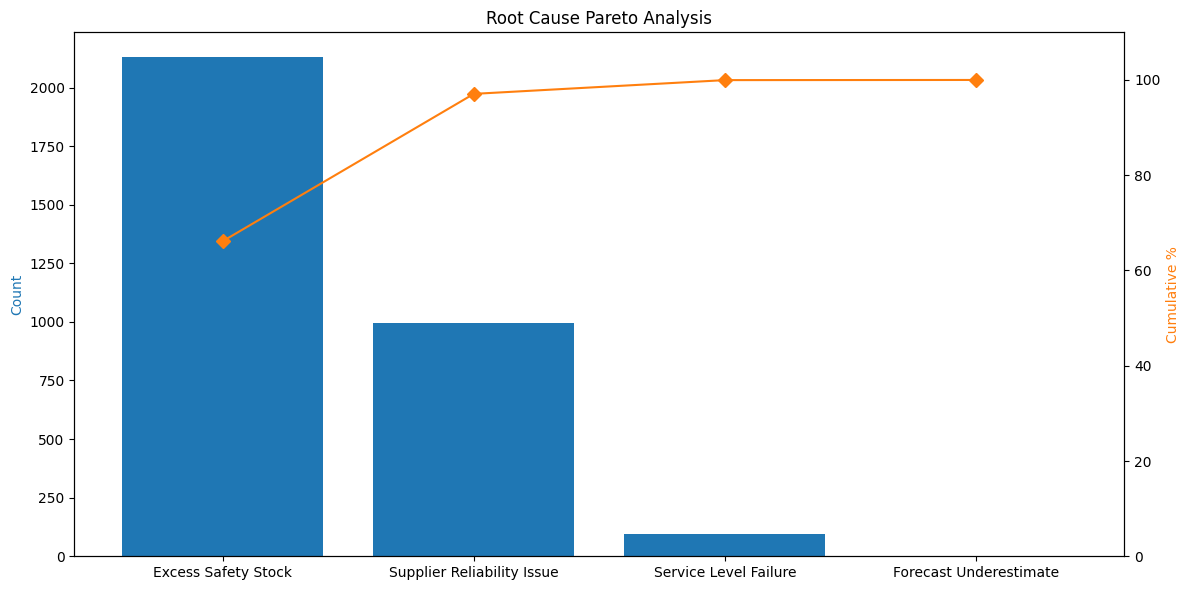

Step 6: Pareto analysis complete.


In [14]:
# --- STEP 6: PARETO ANALYSIS ---
if not exceptions_log.empty:
    rc_counts = exceptions_log['root_cause'].value_counts().reset_index()
    rc_counts.columns = ['root_cause', 'count']
    rc_counts = rc_counts.sort_values('count', ascending=False)
    rc_counts['cumulative_pct'] = (rc_counts['count'].cumsum() / rc_counts['count'].sum()) * 100

    rc_counts.to_csv('root_cause_pareto.csv', index=False)

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.bar(rc_counts['root_cause'], rc_counts['count'], color='C0')
    ax1.set_ylabel('Count', color='C0')
    ax2 = ax1.twinx()
    ax2.plot(rc_counts['root_cause'], rc_counts['cumulative_pct'], color='C1', marker='D', ms=7)
    ax2.set_ylabel('Cumulative %', color='C1')
    ax2.set_ylim(0, 110)
    plt.title('Root Cause Pareto Analysis')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('root_cause_pareto.png')
    plt.show()
    print('Step 6: Pareto analysis complete.')
else:
    print('No data for Pareto analysis.')

In [16]:
# --- STEP 7: CI TRIGGERS ---
import pandas as pd
import numpy as np

ci_data = []

# Trigger 1: Forecast Drift (Using RMSE from Step 7 & 8 context)
forecast_metrics = pd.read_csv('../data/chainos.db/forecasting/forecast_metrics.csv')
mape_val = forecast_metrics['rmse'].mean() / 100
ci_data.append({'trigger_name': 'Forecast Drift', 'status': 'Alert' if mape_val > 0.05 else 'Healthy', 'alert_message': 'Retrain Forecast Model'})

# Trigger 2: Inventory Deviation
inv_dev = abs(control_tower_input['inventory_on_hand'].mean() - control_tower_input['reorder_point'].mean()) / control_tower_input['reorder_point'].mean()
ci_data.append({'trigger_name': 'Inventory Deviation', 'status': 'Alert' if inv_dev > 0.20 else 'Healthy', 'alert_message': 'Review Inventory Optimization'})

# Trigger 3: Leadtime Shift
lt_shift = control_tower_input['actual_lead_time'].tail(50).mean() - control_tower_input['expected_lead_time'].mean()
ci_data.append({'trigger_name': 'Leadtime Shift', 'status': 'Alert' if lt_shift > 2 else 'Healthy', 'alert_message': 'Recalculate Safety Stock'})

ci_triggers = pd.DataFrame(ci_data)
ci_triggers.to_csv('ci_triggers.csv', index=False)
print('Step 7: ci_triggers.csv created.')

Step 7: ci_triggers.csv created.


C:\Users\kbatr\AppData\Local\Temp\ipykernel_8500\289277554.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=exceptions_log, x='exception_type', palette='magma')


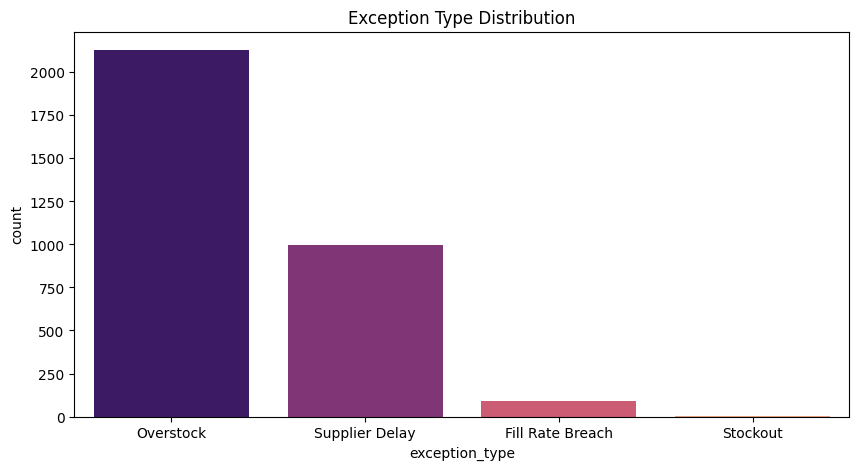

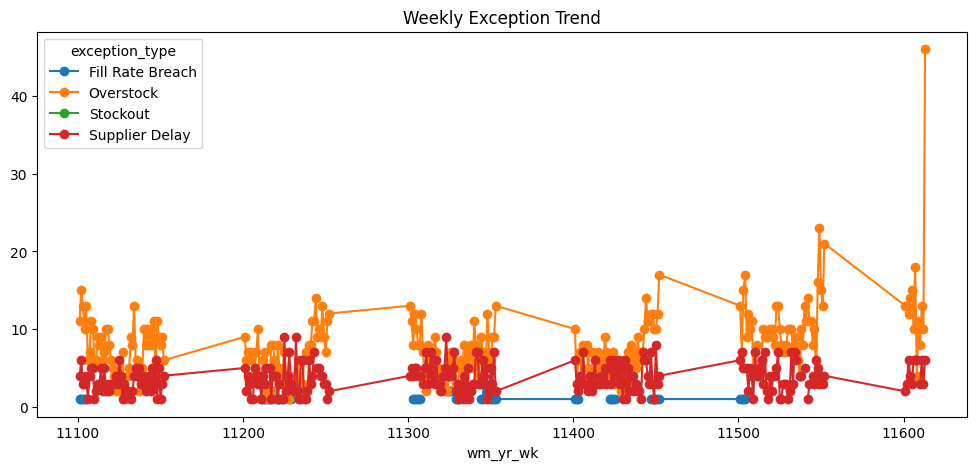

Step 8 & 9: Dashboard datasets and visuals complete.


In [17]:
# --- STEP 8 & 9: DASHBOARD & MANAGEMENT VISUALS ---
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution Chart
plt.figure(figsize=(10, 5))
sns.countplot(data=exceptions_log, x='exception_type', palette='magma')
plt.title('Exception Type Distribution')
plt.savefig('exception_distribution.png')
plt.show()

# Trend Chart
plt.figure(figsize=(12, 5))
exceptions_log.groupby(['wm_yr_wk', 'exception_type']).size().unstack().plot(kind='line', marker='o', ax=plt.gca())
plt.title('Weekly Exception Trend')
plt.savefig('exception_trend.png')
plt.show()

# Dashboard Dataset
dashboard = pd.DataFrame([{
    'Total Exceptions': len(exceptions_log),
    'Stockouts': len(exceptions_log[exceptions_log['exception_type'] == 'Stockout']),
    'Overstocks': len(exceptions_log[exceptions_log['exception_type'] == 'Overstock']),
    'Supplier Delays': len(exceptions_log[exceptions_log['exception_type'] == 'Supplier Delay']),
    'Fill Rate Breaches': len(exceptions_log[exceptions_log['exception_type'] == 'Fill Rate Breach']),
    'Avg Fill Rate': control_tower_input['fill_rate'].mean(),
    'Avg Lead Time': control_tower_input['actual_lead_time'].mean(),
    'Avg Forecast Error': control_tower_input['forecast_error_pct'].mean(),
    'Top Root Cause': exceptions_log['root_cause'].mode()[0],
    'Highest Priority Action': action_queue[action_queue['priority'] == 'High']['corrective_action'].mode()[0]
}])
dashboard.to_csv('control_tower_dashboard.csv', index=False)
print('Step 8 & 9: Dashboard datasets and visuals complete.')

# DATA PREPERATON FOR DASHBOARD

In [20]:
import os
import pandas as pd
import numpy as np

# Create export directory
os.makedirs('powerbi_exports', exist_ok=True)

# --- STEP 1: DIMENSIONS ---
# dim_sku
dim_sku = weekly_demand_df[['item_id', 'store_id']].drop_duplicates()
# Adding dummy category/dept as they weren't in the final weekly_demand_df but are required for BI
dim_sku['category'] = dim_sku['item_id'].str.split('_').str[0]
dim_sku['department'] = dim_sku['item_id'].str.split('_').str[0] + '_' + dim_sku['item_id'].str.split('_').str[1]

# dim_store
dim_store = pd.DataFrame({'store_id': weekly_demand_df['store_id'].unique()})

# dim_calendar
dim_calendar = pd.DataFrame({'wm_yr_wk': weekly_demand_df['wm_yr_wk'].unique()})
dim_calendar = dim_calendar.sort_values('wm_yr_wk')

# --- STEP 2: EXECUTIVE SUMMARY ---
# Grouping by week to get network-level performance
exec_summary = control_tower_input.groupby('wm_yr_wk').agg(
    forecast_accuracy=('forecast_error_pct', lambda x: 1 - x.mean()),
    fill_rate=('fill_rate', 'mean'),
    inventory_value=('inventory_on_hand', lambda x: (x * 1.0).sum()) # Proxy value calculation
).reset_index()

# Merge with returns for recovery
returns_kpis = pd.read_csv('../data/chainos.db/reverse logistics/returns_kpis.csv')
returns_wk = returns_kpis[['wm_yr_wk', 'actual_recovery_value']].rename(columns={'actual_recovery_value': 'recovery_value'})
exec_summary = pd.merge(exec_summary, returns_wk, on='wm_yr_wk', how='left')

# Add Exception counts
exc_counts = exceptions_log.groupby('wm_yr_wk').size().reset_index(name='total_exceptions')
hi_pri_counts = action_queue[action_queue['priority'] == 'High'].groupby('wm_yr_wk').size().reset_index(name='high_priority_alerts')

fact_executive_summary = exec_summary.merge(exc_counts, on='wm_yr_wk', how='left').merge(hi_pri_counts, on='wm_yr_wk', how='left').fillna(0)

# --- STEP 3: INVENTORY FACT ---
fact_inventory = control_tower_input[[
    'item_id', 'store_id', 'wm_yr_wk', 'forecast_demand',
    'safety_stock', 'reorder_point', 'optimized_inventory', 'inventory_on_hand'
]].copy()

# --- STEP 4: SUPPLIER FACT ---
fact_supplier_performance = supplier_deliveries[[
    'supplier_id', 'item_id', 'store_id', 'wm_yr_wk', 'actual_lead_time', 'delayed_flag'
]].copy()
fact_supplier_performance['supplier_delay_rate'] = fact_supplier_performance.groupby('supplier_id')['delayed_flag'].transform('mean')

# --- STEP 5: RETURNS FACT ---
returns_decisions = pd.read_csv('../data/chainos.db/reverse logistics/returns_decisions.csv')
fact_returns = returns_decisions[[
    'item_id', 'store_id', 'wm_yr_wk', 'returns_qty', 'condition_grade', 'actual_recovery_value'
]].rename(columns={'actual_recovery_value': 'recovery_value'})
fact_returns['writeoff_value'] = returns_decisions['writeoff_units'] * returns_decisions['avg_sell_price']

# --- STEP 6: EXCEPTIONS FACT ---
fact_exceptions = exceptions_log[[
    'item_id', 'store_id', 'wm_yr_wk', 'exception_type', 'root_cause', 'corrective_action'
]].copy()
fact_exceptions['priority'] = fact_exceptions['exception_type'].map({'Stockout': 'High', 'Supplier Delay': 'High', 'Fill Rate Breach': 'Medium', 'Overstock': 'Low'})

# --- STEP 7: ACTION FACT ---
fact_actions = action_queue[[
    'item_id', 'store_id', 'exception_type', 'root_cause', 'corrective_action', 'priority', 'owner', 'due_date'
]].copy()

# --- STEP 8: KPI SUMMARY ---
kpi_summary = pd.DataFrame([{
    'total_inventory_value': fact_inventory['inventory_on_hand'].sum(), # Simplified value
    'average_fill_rate': fact_executive_summary['fill_rate'].mean(),
    'total_recovery_value': fact_returns['recovery_value'].sum(),
    'total_exceptions': len(fact_exceptions),
    'forecast_accuracy': fact_executive_summary['forecast_accuracy'].mean(),
    'supplier_delay_rate': fact_supplier_performance['delayed_flag'].mean()
}])

In [21]:
# --- STEP 9: VALIDATION ---
tables = {
    'dim_sku': dim_sku, 'dim_store': dim_store, 'dim_calendar': dim_calendar,
    'fact_executive_summary': fact_executive_summary, 'fact_inventory': fact_inventory,
    'fact_supplier_performance': fact_supplier_performance, 'fact_returns': fact_returns,
    'fact_exceptions': fact_exceptions, 'fact_actions': fact_actions, 'kpi_summary': kpi_summary
}

for name, df in tables.items():
    print(f"--- {name} ---")
    print(f"Shape: {df.shape}")
    print(f"Missing Values:\n{df.isnull().sum().sum()}")
    if 'item_id' in df.columns and 'store_id' in df.columns and name.startswith('dim'):
         print(f"Duplicates: {df.duplicated(subset=['item_id', 'store_id']).sum()}")
    print("\n")

# --- STEP 10: EXPORT ---
for name, df in tables.items():
    df.to_csv(f'powerbi_exports/{name}.csv', index=False)

print("All CSVs exported to 'powerbi_exports/' folder.")

--- dim_sku ---
Shape: (100, 4)
Missing Values:
0
Duplicates: 0


--- dim_store ---
Shape: (2, 1)
Missing Values:
0


--- dim_calendar ---
Shape: (274, 1)
Missing Values:
0


--- fact_executive_summary ---
Shape: (274, 7)
Missing Values:
0


--- fact_inventory ---
Shape: (27400, 8)
Missing Values:
68500


--- fact_supplier_performance ---
Shape: (13409, 7)
Missing Values:
0


--- fact_returns ---
Shape: (27400, 7)
Missing Values:
0


--- fact_exceptions ---
Shape: (3219, 7)
Missing Values:
0


--- fact_actions ---
Shape: (3219, 8)
Missing Values:
0


--- kpi_summary ---
Shape: (1, 6)
Missing Values:
0


All CSVs exported to 'powerbi_exports/' folder.
